In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import processing_fun
importlib.reload(processing_fun)

from utils import OperonArgs

# Av

Searching for a function of galaxy properties which is agnostic to dust mixture

Test if Av is exact or inferred

In [11]:
fname = '../data/merged_bestfit_galprops_SMC.dat'
df_fit = pd.read_csv(fname, sep=r'\s+', usecols=["#galaxy_id", "los", "Av"])
df_fit.rename(columns={'#galaxy_id': 'galaxy_id'}, inplace=True)

fname = '../data/gal_los_iobcomp_attcurve_galprop_29_01_SMC.dat'
df_data = pd.read_csv(fname, sep=r'\s+', usecols=["galaxy_id", "los", "A_5542A"])

# Merge the two dataframes on galaxy_id and los
df_merged = pd.merge(df_fit, df_data, on=['galaxy_id', 'los'])

# See if the two equal
print(np.all(df_merged['Av'] == df_merged['A_5542A']))

True


Operon fits


Reading from configuration file: conf/Av_0.ini

Reading from selection file: conf/selection_0.ini

All model lengths:
[ 5  6  7  8 10 11 12 13 15 17 18 19 20 21 22 23 24]

Equation requested:
((-0.007631) + (0.999887 * ((0.028951 * X4) - (((-0.002148) * X9) - ((((log((9287.586914 * X21)) - (104.065773 * X5)) - ((-0.730887) * X31)) - ((-3.164968) * X30)) * (log((6391.147949 * X20)) * (log((209002.921875 * X31)) * (0.033974 * X5))))))))


100%|██████████| 17/17 [00:14<00:00,  1.18it/s]



Latex version:
SFR_{compact} b_{0} + Z_{gas} b_{1} \left(- Z_{gas} b_{2} + b_{3} r_{StarYoungOverRgas} + b_{4} r_{StarYoungOverRgasSF} + \log{\left(\Sigma_{SFR100old} b_{5} \right)}\right) \log{\left(\Sigma_{SFR10young} b_{6} \right)} \log{\left(b_{7} r_{StarYoungOverRgasSF} \right)} + b_{8} r_{gasSF} - b_{9}

Number of parameters: 10
Values: [0.028947728537, 0.033970160938, 104.065773, 3.164968, 0.730887, 9287.586914, 6391.147949, 209002.921875, 0.002147757276, 0.007631]

1 - R2 for chosen model:
Training: 0.2569
Validation: 0.2404


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

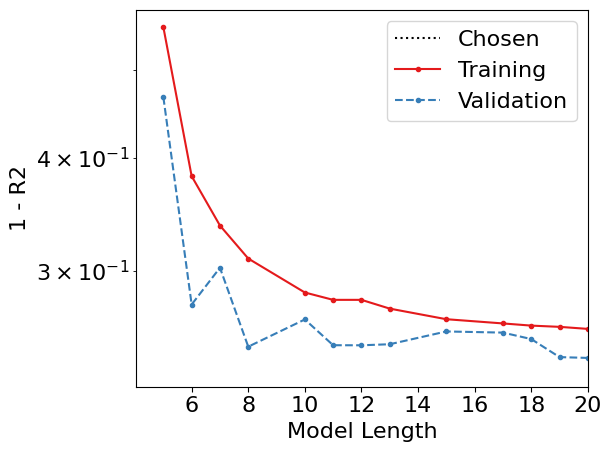

In [2]:
ini_file = 'conf/Av_0.ini'; ilen = None
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)

# $B_0$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust


Reading from configuration file: conf/B0_0.ini

Reading from selection file: conf/selection_1.ini

All model lengths:
[ 5  6  8  9 10 11 12 13 14 15 16 17 19 21 22 23 24]

Equation requested:
((-0.853433) + (0.323353 * (exp((0.535869 * X4)) - ((-0.000290) * X3))))


100%|██████████| 17/17 [00:00<00:00, 81.62it/s]



Latex version:
B_{2} b_{0} + b_{1} e^{B_{3} b_{2}} - b_{3}

Number of parameters: 4
Values: [9.377237e-05, 0.323353, 0.535869, 0.853433]

1 - R2 for chosen model:
Training: 0.0131
Validation: 0.0080


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

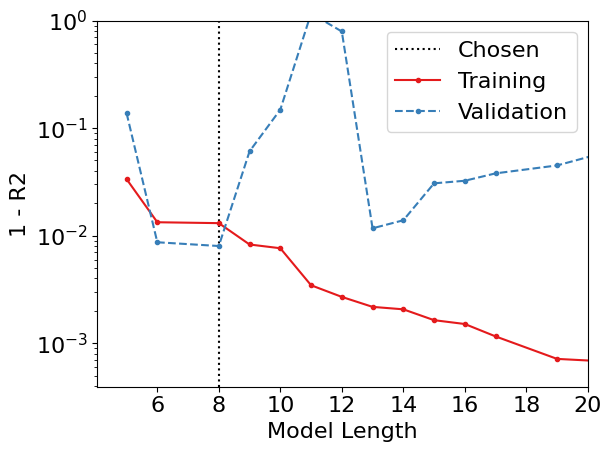

In [5]:
ini_file = 'conf/B0_0.ini'; ilen = 8
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)

## SMC dust


Reading from configuration file: conf/B0_1.ini

Reading from selection file: conf/selection_3.ini

All model lengths:
[ 5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
(0.001030 + (1.004424 * ((((((-0.000145) * X2) - ((-0.009171) * X1)) * (1.584905 + ((-0.287748) * X4))) * exp(((((-6.327424) * X4) + ((-0.016131) * X3)) * ((0.000275 * X3) + (((-0.098540) * X1) + exp(((-19.079748) * X1))))))) ^ 2)))


100%|██████████| 19/19 [00:09<00:00,  1.99it/s]



Latex version:
b_{0} \left(A_{V} b_{3} - B_{1} b_{4}\right)^{2} \left(- B_{3} b_{2} + b_{1}\right)^{2} e^{\left(- 2 B_{2} b_{5} - 2 B_{3} b_{6}\right) \left(- A_{V} b_{7} + B_{2} b_{8} + e^{- A_{V} b_{9}}\right)} + b_{10}

Number of parameters: 11
Values: [1.004424, 1.584905, 0.287748, 0.009171, 0.000145, 0.016131, 6.327424, 0.09854, 0.000275, 19.079748, 0.00103]

1 - R2 for chosen model:
Training: 0.3556
Validation: 56.1863


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

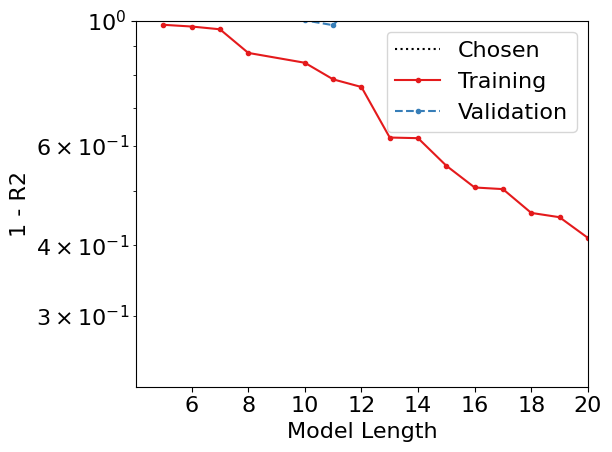

In [6]:
ini_file = 'conf/B0_1.ini'; ilen = None
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)

## Stellar dust

# $B_1$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B1_0.ini

Reading from selection file: conf/selection_2.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 17 18 19 20 21 22 23 24]

Equation requested:
((-592.701111) + (10299.539062 * ((0.707107 * X5) / (3.185982 * X34))))


100%|██████████| 19/19 [00:00<00:00, 34.16it/s]



Latex version:
- b_{0} + \frac{Z_{gas} b_{1}}{A_{V}}

Number of parameters: 2
Values: [592.701111, 2285.91252791561]

1 - R2 for chosen model:
Training: 0.1511
Validation: 0.0356


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

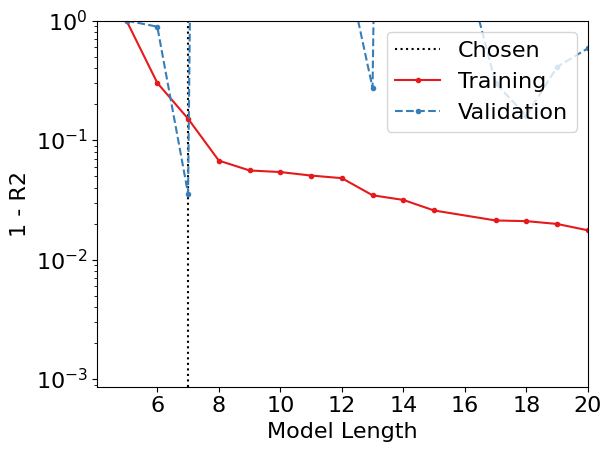

In [8]:
ini_file = 'conf/B1_0.ini'; ilen = 7
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)

# $B_2$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust


Reading from configuration file: conf/B2_0.ini

Reading from selection file: conf/selection_1.ini

All model lengths:
[ 5  6  7  8  9 10 11 13 14 15 16 17 18 20 21 22 23 24]

Equation requested:
((-327.836395) + (1.348244 * ((exp((0.003368 * X2)) - ((-436.476624) * X2)) - (1.473170 * X3))))


  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 71.86it/s]



Latex version:
B_{0} b_{0} - B_{1} b_{1} + b_{2} e^{B_{0} b_{3}} - b_{4}

Number of parameters: 5
Values: [588.476989448256, 1.98619261348, 1.348244, 0.003368, 327.836395]

1 - R2 for chosen model:
Training: 0.0575
Validation: 0.1103


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

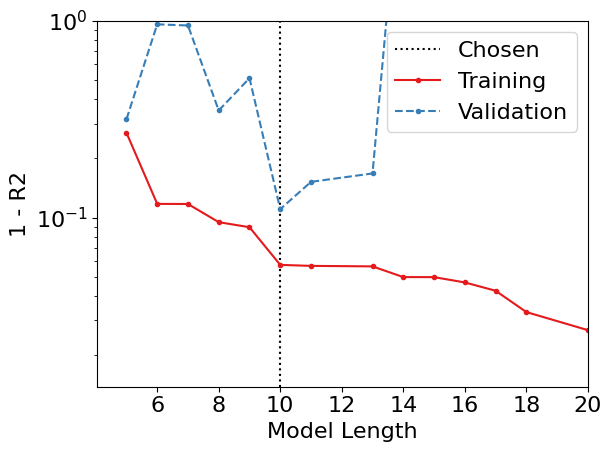

In [10]:
ini_file = 'conf/B2_0.ini'; ilen = 10
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)

## SMC dust


Reading from configuration file: conf/B2_1.ini

Reading from selection file: conf/selection_3.ini

All model lengths:
[ 5  6  7  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
((-1980.704590) + (0.835113 * (((2.130682 * X4) / ((-0.591440) * X1)) + (((-13318548.000000) * X3) - ((-13318545.000000) * X3)))))


100%|██████████| 18/18 [00:00<00:00, 83.41it/s]



Latex version:
- B_{1} b_{0} - b_{1} - \frac{B_{3} b_{2}}{A_{V}}

Number of parameters: 3
Values: [2.505339, 1980.70459, 3.00852197529082]

1 - R2 for chosen model:
Training: 0.0028
Validation: 0.1347


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

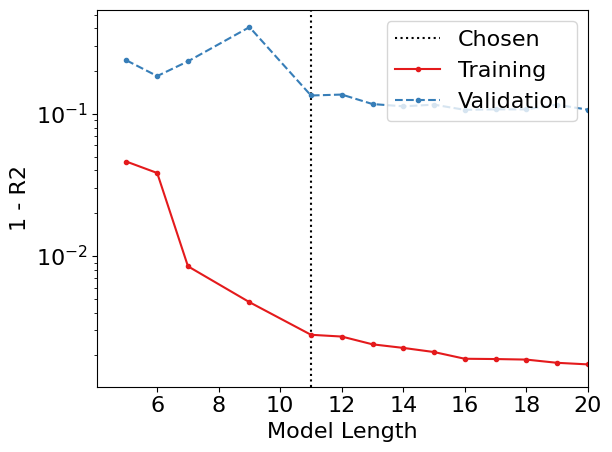

In [12]:
ini_file = 'conf/B2_1.ini'; ilen = 11
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)

## Stellar dust

# $B_3$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B3_0.ini

Reading from selection file: conf/selection_2.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 24]

Equation requested:
((-0.283124) + (1.077526 * (((-0.064901) * X32) + ((log(sqrt((0.000050 * X29))) - ((((log((0.000000 * X20)) * ((-0.013108) * X2)) - (((-0.086211) * X4) - log((0.000000 * X34)))) ^ 2) * ((-0.004407) * X1))) - (0.125010 * X31)))))


100%|██████████| 18/18 [00:11<00:00,  1.61it/s]



Latex version:
- b_{0} r_{StarOldOverRStaryoung} - b_{1} r_{StarYoungOverRgasSF} + b_{2} \left(SFR_{compact} b_{3} + \tilde{\infty} \log{\left(M_{gas} \right)} + \tilde{\infty}\right)^{2} \log{\left(M_{star} \right)} + b_{4} \log{\left(b_{5} \sqrt{r_{StarOldOverRgasSF}} \right)} - b_{6}

Number of parameters: 7
Values: [0.069932514926, 0.13470152526, 0.004748657082, 0.086211, 1.077526, 0.00707106781186548, 0.283124]

1 - R2 for chosen model:
Training: 0.0764
Validation: 0.0910


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

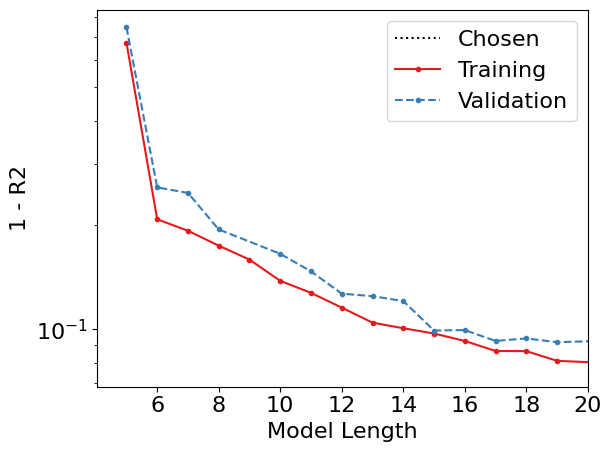

In [13]:
ini_file = 'conf/B3_0.ini'; ilen = None
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='log', loss_max=1.0)